Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: X=(20640, 8) | y=(20640,)
Target range: 0.15 – 5.00 ($100k)

Train: 14912 | Val: 2632 | Test: 3096


Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape            ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 8)               │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)             │         2,304 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)             │         1,024 │
│ (BatchNormalization)            │                         │               │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)             │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)             │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)             │        32,896 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)             │           512 │
│ (BatchNormalization)            │                         │               │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)             │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)             │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)              │         8,256 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)              │           256 │
│ (BatchNormalization)            │                         │               │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)              │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)              │             0 │
├─────────────────────────────────┼─────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)               │            65 │
└─────────────────────────────────┴─────────────────────────┴───────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 44,417 (173.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.2805 - mae: 0.8359 - val_loss: 2.8834 - val_mae: 1.4035 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6881 - mae: 0.6141 - val_loss: 1.6426 - val_mae: 0.9977 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6066 - mae: 0.5743 - val_loss: 1.0753 - val_mae: 0.7378 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5698 - mae: 0.5534 - val_loss: 0.7298 - val_mae: 0.5814 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5235 - mae: 0.5297 - val_loss: 0.6385 - val_mae: 0.5380 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4963 - mae: 0.5180 - val_loss: 0.5947 - val_mae: 0.5167 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4664 - mae: 0.4984 - val_loss: 0.5488 - val_mae: 0.4882 - learning_rate: 0.0010
Epoch 8/200


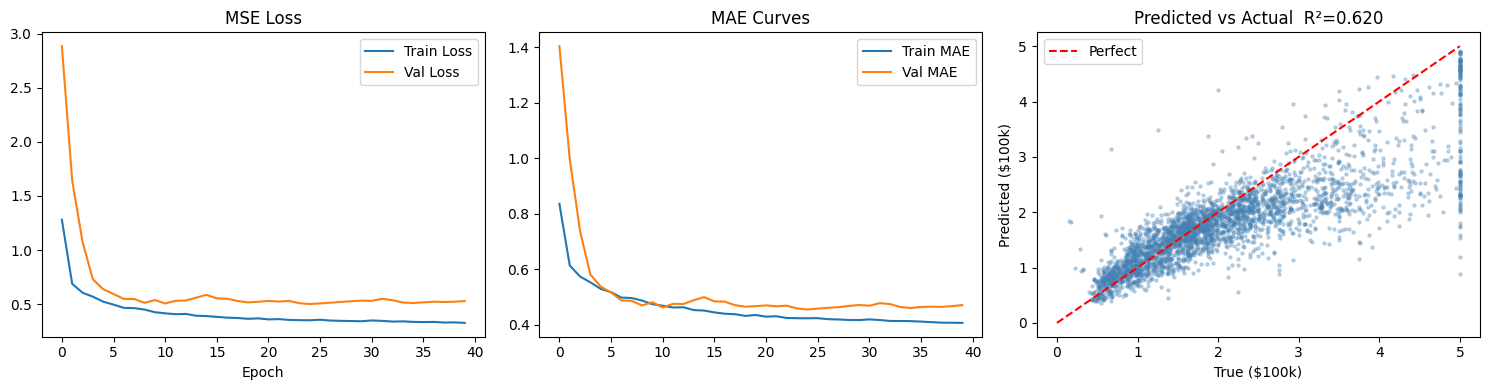

In [1]:
# ============================================================
# CALIFORNIA HOUSING — REGRESSION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

tf.random.set_seed(42)
np.random.seed(42)

# ── 1. LOAD DATA ──────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32)

print(f"Features: {housing.feature_names}")
print(f"Shape: X={X.shape} | y={y.shape}")
print(f"Target range: {y.min():.2f} – {y.max():.2f} ($100k)")

# ── 2. PREPROCESSING ──────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── 3. MODEL (Functional API) ─────────────────────────────
def build_house_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='features')
    x = keras.layers.Dense(256)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(128)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(64)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.1)(x)

    outputs = keras.layers.Dense(1, name='price_output')(x)
    return keras.Model(inputs, outputs, name='HousePriceANN')

model = build_house_model(input_dim=8)
model.summary()

# ── 4. COMPILE ────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# ── 5. CALLBACKS ──────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_house_model.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

# ── 6. TRAIN ──────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=200, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

# ── 7. EVALUATE ───────────────────────────────────────────
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== TEST RESULTS ===")
print(f"MSE: {results[0]:.4f}")
print(f"MAE: {results[1]:.4f}  (${results[1]*100:.0f}k average error)")

y_pred = model.predict(X_test, verbose=0).flatten()
r2     = r2_score(y_test, y_pred)
print(f"R²:  {r2:.4f}  (1.0 = perfect)")

# ── 8. VISUALIZE ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curves')
axes[1].legend()

axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
axes[2].plot([0, 5], [0, 5], 'r--', label='Perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('Predicted ($100k)')
axes[2].set_title(f'Predicted vs Actual  R²={r2:.3f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('house_price_results.png', dpi=150)
plt.show()